# Flow Matching: Space Mapping (CSTR Design)

Map desired concentrations $(C_a, C_b)$ to design parameters $(R, RT)$ for a CSTR.

**Authors:** Victor Alves and John R. Kitchin

## System Information

This section documents the computational environment used to run this notebook.

In [1]:
import sys
import platform
import time
import psutil
import os

print("System Information")
print("=" * 70)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"CPU count: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"Total memory: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("=" * 70)

# Key package versions
print("\nKey Library Versions:")
print("-" * 70)
packages = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sklearn', 'sklearn'),
    ('torch', 'torch'),
    ('gmr', 'gmr'),
]

for pkg_name, import_name in packages:
    try:
        mod = __import__(pkg_name)
        version = getattr(mod, '__version__', 'unknown')
        print(f"{pkg_name:<20} {version}")
    except ImportError:
        print(f"{pkg_name:<20} NOT INSTALLED")

print("-" * 70)

# Initialize timing and memory tracking
_start_time = time.time()
_process = psutil.Process(os.getpid())
_start_memory_mb = _process.memory_info().rss / (1024 * 1024)

print(f"\nNotebook execution started: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"Initial memory usage: {_start_memory_mb:.2f} MB")
print("=" * 70)

System Information
Python version: 3.12.8 (main, Jan 14 2025, 23:36:58) [Clang 19.1.6 ]
Platform: macOS-15.7.2-arm64-arm-64bit
Processor: arm
CPU count: 14 physical, 14 logical
Total memory: 64.00 GB

Key Library Versions:
----------------------------------------------------------------------
numpy                2.3.4
scipy                1.16.2
matplotlib           3.10.1


sklearn              1.7.2


torch                2.4.1
gmr                  2.0.2
----------------------------------------------------------------------

Notebook execution started: 2025-12-18 10:01:50
Initial memory usage: 319.08 MB


## System Information

This section documents the computational environment used to run this notebook.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import os

# Force CPU for JAX (must be set before importing JAX)
os.environ['JAX_PLATFORMS'] = 'cpu'

import torch

# Import reusable utilities from local module
from generative_optimization import (
    generate_samples,
    cluster_stats,
    ConditionalFlowMatching
)

# Force CPU for PyTorch
device = torch.device('cpu')
print(f"Using device: {device}")

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150

warnings.filterwarnings('ignore')

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


## Problem Setup

CSTR with reactions:
$$2A \xrightarrow{k_1} B$$
$$B \xrightarrow{k_2} C$$

Design parameters:
- $R$: reactor radius
- $RT$: dimensionless temperature parameter

Outputs:
- $C_a$: exit concentration of A
- $C_b$: exit concentration of B

**Inverse problem**: Given desired $(C_a, C_b)$, find $(R, RT)$.

In [3]:
# CSTR model
H = 1
vo = 1
Cao = 1

bounds = [[0.1, 3], [0.1, 15]]
X = generate_samples(bounds, n_samples=1024, seed=42)

R, RT = X.T
V = np.pi * R**2 * H
k1 = np.exp(-3 / RT)
k2 = np.exp(-10 / RT)

a = V * k1
b = vo + V * k2
c = -vo * Cao
Ca = (-b + np.sqrt(b**2 - 4*a*c)) / (2*a)
Cb = k1 * Ca**2 * V / vo

print(f"Ca range: [{Ca.min():.3f}, {Ca.max():.3f}]")
print(f"Cb range: [{Cb.min():.3f}, {Cb.max():.3f}]")

Ca range: [0.061, 1.000]
Cb range: [0.000, 0.623]


In [4]:
# Train: generate [R, RT] conditioned on [Ca, Cb]
x_data = np.column_stack([R, RT])
c_data = np.column_stack([Ca, Cb])

fm_map = ConditionalFlowMatching(x_dim=2, c_dim=2, hidden_dim=128, n_layers=4)
losses = fm_map.fit(x_data, c_data, epochs=1000, batch_size=64)

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

In [5]:
# Map desired output region to input space
center = (0.58, 0.3)
radius = 0.08

# Generate points in desired circle
theta = np.random.uniform(0, 2*np.pi, 500)
r = np.sqrt(np.random.uniform(0, 1, 500)) * radius
Ca_desired = center[0] + r * np.cos(theta)
Cb_desired = center[1] + r * np.sin(theta)

# Map to input space
c_values = np.column_stack([Ca_desired, Cb_desired])
mapped = []
for c in c_values:
    s = fm_map.sample(c_values=[c], n_samples=1)
    mapped.append(s[0])
mapped = np.array(mapped)

print(f"Mapped {len(mapped)} points")

Mapped 500 points


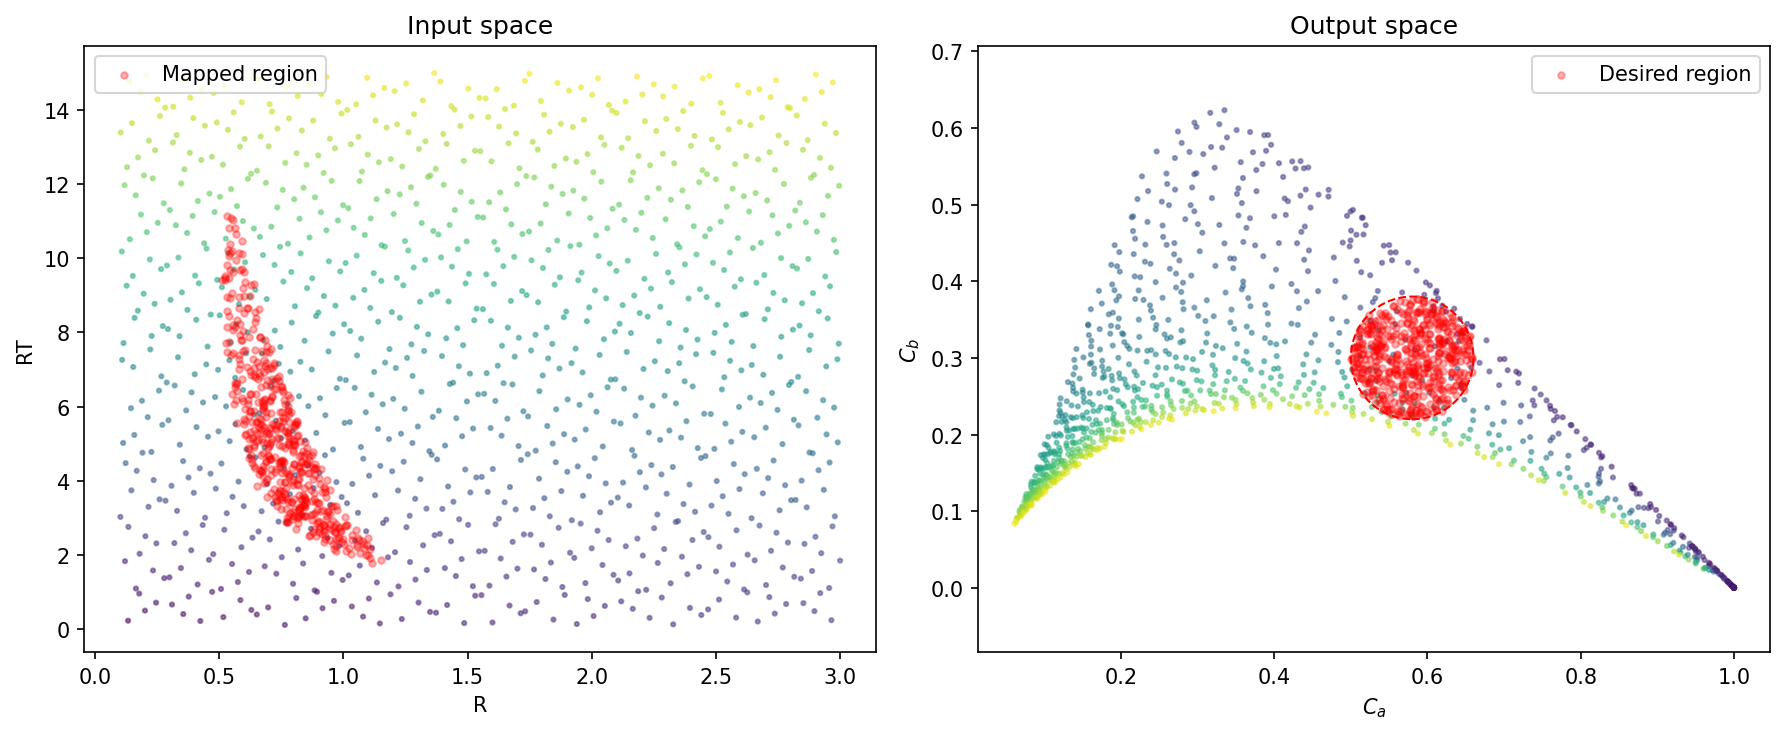

In [6]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = np.sqrt(R**2 + RT**2)

# Input space
axes[0].scatter(R, RT, s=4, c=colors, cmap='viridis', alpha=0.5)
axes[0].scatter(mapped[:, 0], mapped[:, 1], c='red', s=10, alpha=0.3, 
                label='Mapped region')
axes[0].set_xlabel('R')
axes[0].set_ylabel('RT')
axes[0].set_title('Input space')
axes[0].legend()

# Output space
axes[1].scatter(Ca, Cb, s=4, c=colors, cmap='viridis', alpha=0.5)
axes[1].scatter(Ca_desired, Cb_desired, c='red', s=10, alpha=0.3,
                label='Desired region')
circle = plt.Circle(center, radius, fill=False, color='red', ls='--')
axes[1].add_patch(circle)
axes[1].set_xlabel('$C_a$')
axes[1].set_ylabel('$C_b$')
axes[1].set_title('Output space')
axes[1].axis('equal')
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
# Final timing and memory report
_end_time = time.time()
_end_memory_mb = _process.memory_info().rss / (1024 * 1024)
_elapsed_seconds = _end_time - _start_time

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION SUMMARY")
print("=" * 70)
print(f"Start time:      {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"End time:        {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_end_time))}")
print(f"Elapsed time:    {_elapsed_seconds:.2f} seconds ({_elapsed_seconds/60:.2f} minutes)")
print("-" * 70)
print(f"Initial memory:  {_start_memory_mb:.2f} MB")
print(f"Final memory:    {_end_memory_mb:.2f} MB")
print(f"Memory change:   {_end_memory_mb - _start_memory_mb:+.2f} MB")
print("=" * 70)


NOTEBOOK EXECUTION SUMMARY
Start time:      2025-12-18 10:01:50
End time:        2025-12-18 10:02:07
Elapsed time:    17.06 seconds (0.28 minutes)
----------------------------------------------------------------------
Initial memory:  319.08 MB
Final memory:    439.59 MB
Memory change:   +120.52 MB
